In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
#  LOAD DATA

df = pd.read_csv("aqi_dataset.csv")

print("Original Data:")
print(df)

Original Data:
         City        Date   PM25   PM10   NO2
0   Ahmedabad  2024-01-01  120.0  200.0  40.0
1   Ahmedabad  2024-01-02  150.0  240.0  55.0
2   Ahmedabad  2024-01-03    NaN  220.0  50.0
3      Mumbai  2024-01-01   90.0  180.0  35.0
4      Mumbai  2024-01-02  100.0    NaN  45.0
5      Mumbai  2024-01-03   95.0  170.0   NaN
6       Delhi  2024-01-01  200.0  300.0  60.0
7       Delhi  2024-01-02  210.0  320.0  65.0
8       Delhi  2024-01-03    NaN  310.0  70.0
9   Bangalore  2024-01-01   70.0  150.0  30.0
10  Bangalore  2024-01-02   65.0  140.0   NaN
11  Bangalore  2024-01-03   75.0    NaN  28.0


In [25]:
# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])


In [24]:
# 3️⃣ HANDLE MISSING VALUES
# (City-wise mean imputation)
# ---------------------------------
pollutants = ["PM25", "PM10", "NO2"]

for col in pollutants:
    df[col] = df.groupby("City")[col].transform(
        lambda x: x.fillna(x.mean())
    )

print("\nAfter Handling Missing Values:")
print(df)


After Handling Missing Values:
         City        Date   PM25   PM10   NO2
0   Ahmedabad  2024-01-01  120.0  200.0  40.0
1   Ahmedabad  2024-01-02  150.0  240.0  55.0
2   Ahmedabad  2024-01-03  135.0  220.0  50.0
3      Mumbai  2024-01-01   90.0  180.0  35.0
4      Mumbai  2024-01-02  100.0  175.0  45.0
5      Mumbai  2024-01-03   95.0  170.0  40.0
6       Delhi  2024-01-01  200.0  300.0  60.0
7       Delhi  2024-01-02  210.0  320.0  65.0
8       Delhi  2024-01-03  205.0  310.0  70.0
9   Bangalore  2024-01-01   70.0  150.0  30.0
10  Bangalore  2024-01-02   65.0  140.0  29.0
11  Bangalore  2024-01-03   75.0  145.0  28.0


In [27]:
# 4 FEATURE ENGINEERING
# ---------------------------------
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

# Pollution Ratio
df["PM_Ratio"] = df["PM25"] / (df["PM10"] + 1)

print("\nAfter Feature Engineering:")
print(df)



After Feature Engineering:
         City       Date   PM25   PM10   NO2  Month  Day    Weekday  PM_Ratio
0   Ahmedabad 2024-01-01  120.0  200.0  40.0      1    1     Monday  0.597015
1   Ahmedabad 2024-01-02  150.0  240.0  55.0      1    2    Tuesday  0.622407
2   Ahmedabad 2024-01-03  135.0  220.0  50.0      1    3  Wednesday  0.610860
3      Mumbai 2024-01-01   90.0  180.0  35.0      1    1     Monday  0.497238
4      Mumbai 2024-01-02  100.0  175.0  45.0      1    2    Tuesday  0.568182
5      Mumbai 2024-01-03   95.0  170.0  40.0      1    3  Wednesday  0.555556
6       Delhi 2024-01-01  200.0  300.0  60.0      1    1     Monday  0.664452
7       Delhi 2024-01-02  210.0  320.0  65.0      1    2    Tuesday  0.654206
8       Delhi 2024-01-03  205.0  310.0  70.0      1    3  Wednesday  0.659164
9   Bangalore 2024-01-01   70.0  150.0  30.0      1    1     Monday  0.463576
10  Bangalore 2024-01-02   65.0  140.0  29.0      1    2    Tuesday  0.460993
11  Bangalore 2024-01-03   75.0  145

In [28]:
# =================================
# 5. BASIC ANALYSIS
# =================================

# City-wise Average Pollution
pollutants = ["PM25", "PM10", "NO2"]

city_avg = df.groupby("City")[pollutants].mean()

print("\nCity-wise Average Pollution:")
print(city_avg)



City-wise Average Pollution:
            PM25   PM10        NO2
City                              
Ahmedabad  135.0  220.0  48.333333
Bangalore   70.0  145.0  29.000000
Delhi      205.0  310.0  65.000000
Mumbai      95.0  175.0  40.000000


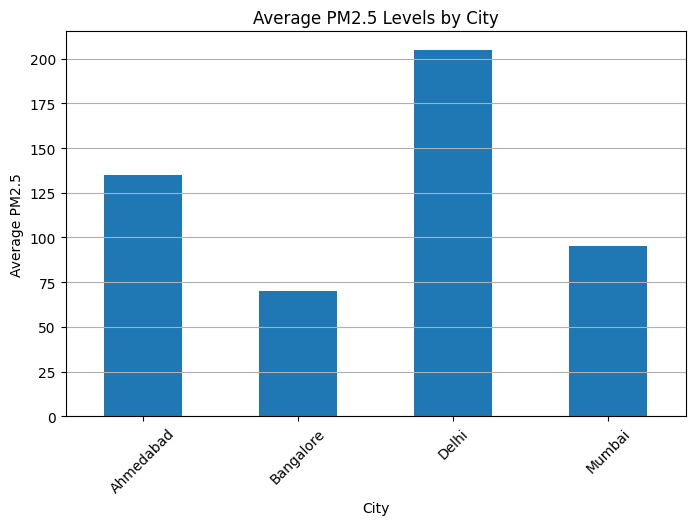

In [32]:
# =================================
# VISUALIZATION 1: Average PM2.5 by City
# =================================

city_avg_pm25 = df.groupby("City")["PM25"].mean()

plt.figure(figsize=(8,5))
city_avg_pm25.plot(kind="bar")

plt.title("Average PM2.5 Levels by City")
plt.xlabel("City")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


In [30]:
# =================================
# 7. SAVE CLEANED DATA
# =================================

df.to_csv("cleaned_air_quality.csv", index=False)

print("\nCleaned dataset saved successfully!")



Cleaned dataset saved successfully!
